# CSCI 567 — Pre-final: Temporally Robust and Fair Credit Risk Prediction
**LendingClub 2007–2018**

- Exp 1: Temporal Robustness — temporal vs random split AUC drop
- Exp 2: Model Design Effects — hyperparameter sweep
- Exp 3: Fairness Analysis — credit history group + income group
- Exp 4: Robustness–Fairness Trade-off
- Exp 5: Neural Network
- Annual AUC trend (2015, 2016, 2017, 2018)

## 0. Setup Environment & Data Load

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# !cp "/content/drive/MyDrive/Colab Notebooks/CSCI567/lendingclub/archive.zip" /content/
# !unzip -q /content/archive.zip -d /content/

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# df = pd.read_csv('/content/accepted_2007_to_2018Q4.csv.gz', low_memory=False)

df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/CSCI567/accepted_2007_to_2018Q4.csv',
    low_memory=False
)

print(f'Raw shape: {df.shape}')

Raw shape: (2260701, 151)


## 1. Preprocessing

In [4]:

# ── Target Creation ──────────────────────────────────────────────────────────
default_labels = ['Charged Off', 'Default',
                  'Does not meet the credit policy. Status:Charged Off']
df['target'] = df['loan_status'].isin(default_labels).astype(int)

# ── Date Parsing ──────────────────────────────────────────────────────────
df['issue_d']  = pd.to_datetime(df['issue_d'],         format='%b-%Y')
df['issue_year'] = df['issue_d'].dt.year
df['age_proxy'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
df['credit_history_years'] = (df['issue_d'] - df['age_proxy']).dt.days / 365

# ── Feature Selection ──────────────────────────────────────────────────────────
FEATURES = ['loan_amnt', 'int_rate', 'installment', 'annual_inc',
            'dti', 'delinq_2yrs', 'fico_range_low', 'open_acc',
            'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
            'mort_acc', 'pub_rec_bankruptcies']

# ── Sampling (Colab) ──────────────────────────────────────────────
df_sample = df.sample(n=200000, random_state=42).copy()
# df_sample = df.copy()
print(f'Sample shape: {df_sample.shape}')
print(f'Default rate: {df_sample["target"].mean():.3f}')

Sample shape: (200000, 155)
Default rate: 0.119


In [5]:
# Fairness groups will be created after splitting so the cutoffs are learned
# from the temporal training data only.
print('Fairness groups will be built after the split step.')

Fairness groups will be built after the split step.


## 2. Data Splitting

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Temporal split: train / val / test ───────────────────────────────────────
train_t = df_sample[df_sample['issue_year'] <= 2013].copy()
val_t   = df_sample[(df_sample['issue_year'] >= 2014) & (df_sample['issue_year'] <= 2015)].copy()
test_t  = df_sample[df_sample['issue_year'] >= 2016].copy()

# ── Random split: train / val / test ─────────────────────────────────────────
rand_train_df, rand_temp_df = train_test_split(
    df_sample, test_size=0.30, random_state=42, stratify=df_sample['target'])

rand_val_df, rand_test_df = train_test_split(
    rand_temp_df, test_size=0.50, random_state=42, stratify=rand_temp_df['target'])

# ── Imputation: learn medians from training splits only ──────────────────────
temporal_fill = train_t[FEATURES + ['credit_history_years']].median()
random_fill   = rand_train_df[FEATURES + ['credit_history_years']].median()

for split_df in [train_t, val_t, test_t]:
    split_df[FEATURES + ['credit_history_years']] = split_df[FEATURES + ['credit_history_years']].fillna(temporal_fill)

for split_df in [rand_train_df, rand_val_df, rand_test_df]:
    split_df[FEATURES + ['credit_history_years']] = split_df[FEATURES + ['credit_history_years']].fillna(random_fill)

# ── Fairness groups: learn cutoffs from temporal train only ──────────────────
credit_bins = pd.qcut(train_t['credit_history_years'], q=3, retbins=True, duplicates='drop')[1]
income_clip_top = train_t['annual_inc'].quantile(0.99)
income_bins = pd.qcut(train_t['annual_inc'].clip(upper=income_clip_top), q=3, retbins=True, duplicates='drop')[1]

credit_bins[0] = -np.inf
credit_bins[-1] = np.inf
income_bins[0] = -np.inf
income_bins[-1] = np.inf

for split_df in [train_t, val_t, test_t, rand_train_df, rand_val_df, rand_test_df]:
    split_df['credit_group'] = pd.cut(split_df['credit_history_years'], bins=credit_bins, labels=['short', 'mid', 'long'], include_lowest=True)
    split_df['income_group'] = pd.cut(split_df['annual_inc'].clip(upper=income_clip_top), bins=income_bins, labels=['low', 'mid', 'high'], include_lowest=True)

X_train_t = train_t[FEATURES]
y_train_t = train_t['target']
X_val_t   = val_t[FEATURES]
y_val_t   = val_t['target']
X_test_t  = test_t[FEATURES]
y_test_t  = test_t['target']

X_rand_tr  = rand_train_df[FEATURES]
y_rand_tr  = rand_train_df['target']
X_rand_val = rand_val_df[FEATURES]
y_rand_val = rand_val_df['target']
X_rand_te  = rand_test_df[FEATURES]
y_rand_te  = rand_test_df['target']

# ── Scaling: fit each scaler on its own training split only ──────────────────
scaler_t = StandardScaler()
X_train_t_sc = scaler_t.fit_transform(X_train_t)
X_val_t_sc   = scaler_t.transform(X_val_t)
X_test_t_sc  = scaler_t.transform(X_test_t)

scaler_r = StandardScaler()
X_rand_tr_sc  = scaler_r.fit_transform(X_rand_tr)
X_rand_val_sc = scaler_r.transform(X_rand_val)
X_rand_te_sc  = scaler_r.transform(X_rand_te)

print('Temporal split')
print(f'  Train (<=2013):   {len(X_train_t):,}')
print(f'  Val (2014-2015):  {len(X_val_t):,}')
print(f'  Test (>=2016):    {len(X_test_t):,}')

print('\nRandom split')
print(f'  Train: {len(X_rand_tr):,}')
print(f'  Val:   {len(X_rand_val):,}')
print(f'  Test:  {len(X_rand_te):,}')

print('\nTemporal-train fairness group distribution')
print(train_t['credit_group'].value_counts())
print(train_t['income_group'].value_counts())

Temporal split
  Train (<=2013):   20,286
  Val (2014-2015):  58,114
  Test (>=2016):    121,596

Random split
  Train: 140,000
  Val:   30,000
  Test:  30,000

Temporal-train fairness group distribution
credit_group
mid      6775
short    6764
long     6747
Name: count, dtype: int64
income_group
low     7220
high    6728
mid     6338
Name: count, dtype: int64


In [7]:
# ── By year temporal test sets (AUC over time) ──────────────────────────────
yearly_tests = {}
for yr in [2016, 2017, 2018]:
    sub = df_sample[df_sample['issue_year'] == yr].copy()
    if len(sub) > 0:
        sub[FEATURES + ['credit_history_years']] = sub[FEATURES + ['credit_history_years']].fillna(temporal_fill)
        sub['credit_group'] = pd.cut(sub['credit_history_years'], bins=credit_bins, labels=['short', 'mid', 'long'], include_lowest=True)
        sub['income_group'] = pd.cut(sub['annual_inc'].clip(upper=income_clip_top), bins=income_bins, labels=['low', 'mid', 'high'], include_lowest=True)
        yearly_tests[yr] = (sub[FEATURES], sub['target'], scaler_t.transform(sub[FEATURES]), sub)
        print(f'{yr}: {len(sub):,} samples, default rate={sub["target"].mean():.3f}')

2016: 38,347 samples, default rate=0.156
2017: 39,269 samples, default rate=0.090
2018: 43,980 samples, default rate=0.017


## 3. Model Definition — Full Model + Hyperparameter Sweep


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# ── All Model Definitions ─────────────────────────────────────────────────────
# LR: C Value sweep (regularization strength)
# Tree: max_depth sweep
# RF: n_estimators x max_depth
# XGB: learning_rate x max_depth
# NN: hidden layer size x alpha (L2)

MODEL_CONFIGS = {
    # Logistic Regression — C sweep
    'LR_C0.001':  (LogisticRegression(C=0.001, max_iter=1000), 'scaled'),
    'LR_C0.01':   (LogisticRegression(C=0.01,  max_iter=1000), 'scaled'),
    'LR_C0.1':    (LogisticRegression(C=0.1,   max_iter=1000), 'scaled'),
    'LR_C1':      (LogisticRegression(C=1,     max_iter=1000), 'scaled'),
    'LR_C10':     (LogisticRegression(C=10,    max_iter=1000), 'scaled'),

    # Decision Tree — depth sweep
    'DTree_d3':   (DecisionTreeClassifier(max_depth=3,  random_state=42), 'raw'),
    'DTree_d5':   (DecisionTreeClassifier(max_depth=5,  random_state=42), 'raw'),
    'DTree_d7': (DecisionTreeClassifier(max_depth=7, random_state=42), "raw"),
    'DTree_d10':  (DecisionTreeClassifier(max_depth=10, random_state=42), 'raw'),

    # Random Forest — n_estimators x depth
    'RF_50_d5':   (RandomForestClassifier(n_estimators=50,  max_depth=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_100_d5':  (RandomForestClassifier(n_estimators=100, max_depth=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_100_d10': (RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1), 'raw'),

    # XGBoost — lr x depth
    'XGB_lr0.01': (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_lr0.1':  (XGBClassifier(n_estimators=100, learning_rate=0.1,  max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d6':     (XGBClassifier(n_estimators=100, learning_rate=0.1,  max_depth=6, eval_metric='logloss', random_state=42), 'raw'),

    # Neural Network — architecture x alpha sweep
    # 'NN_small':   (MLPClassifier(hidden_layer_sizes=(64,),       alpha=0.01, max_iter=200, random_state=42), 'scaled'),
    # 'NN_mid':     (MLPClassifier(hidden_layer_sizes=(128, 64),   alpha=0.01, max_iter=200, random_state=42), 'scaled'),
    # 'NN_large':   (MLPClassifier(hidden_layer_sizes=(256, 128, 64), alpha=0.01, max_iter=200, random_state=42), 'scaled'),
    # 'NN_reg':     (MLPClassifier(hidden_layer_sizes=(128, 64),   alpha=0.1,  max_iter=200, random_state=42), 'scaled'),
}

print(f'Total model configs: {len(MODEL_CONFIGS)}')

Total model configs: 15


## XGBoost Test Code (Find Best)


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# ── All Model Definitions ─────────────────────────────────────────────────────
# LR: C Value sweep (regularization strength)
# Tree: max_depth sweep
# RF: n_estimators x max_depth
# XGB: learning_rate x max_depth
# NN: hidden layer size x alpha (L2)

MODEL_CONFIGS = {
    # 1) Baseline
    'XGB_base':         (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),

    # 2) learning_rate sweep
    'XGB_lr0.01':       (XGBClassifier(n_estimators=100, learning_rate=0.01, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_lr0.05':       (XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_lr0.3':        (XGBClassifier(n_estimators=100, learning_rate=0.3,  max_depth=4, eval_metric='logloss', random_state=42), 'raw'),

    # 3) max_depth sweep
    'XGB_d3':           (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d6':           (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_d8':           (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=8, eval_metric='logloss', random_state=42), 'raw'),

    # 4) min_child_weight sweep
    'XGB_mcw3':         (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, min_child_weight=3,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw5':         (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, min_child_weight=5,  eval_metric='logloss', random_state=42), 'raw'),
    'XGB_mcw10':        (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, min_child_weight=10, eval_metric='logloss', random_state=42), 'raw'),

    # 5) subsample sweep
    'XGB_sub0.6':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, subsample=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.7':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, subsample=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_sub0.8':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, subsample=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # 6) colsample_bytree sweep
    'XGB_col0.6':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, colsample_bytree=0.6, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.7':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, colsample_bytree=0.7, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_col0.8':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, colsample_bytree=0.8, eval_metric='logloss', random_state=42), 'raw'),

    # 7) gamma sweep
    'XGB_gamma1':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, gamma=1, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma3':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, gamma=3, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_gamma5':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, gamma=5, eval_metric='logloss', random_state=42), 'raw'),

    # 8) reg_alpha (L1) sweep
    'XGB_L1_0.1':       (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, reg_alpha=0.1, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_1':         (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, reg_alpha=1.0, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L1_5':         (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, reg_alpha=5.0, eval_metric='logloss', random_state=42), 'raw'),

    # 9) reg_lambda (L2) sweep
    'XGB_L2_1':         (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, reg_lambda=1.0, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2_5':         (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, reg_lambda=5.0, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_L2_10':        (XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, reg_lambda=10.0, eval_metric='logloss', random_state=42), 'raw'),

    # 10) n_estimators sweep
    'XGB_n50':          (XGBClassifier(n_estimators=50,  learning_rate=0.1, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_n200':         (XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
    'XGB_n500':         (XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=4, eval_metric='logloss', random_state=42), 'raw'),
}

print(f'Total model configs: {len(MODEL_CONFIGS)}')

Total model configs: 28


In [10]:
# Reusable evaluation helpers for any model family
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss
import time

def evaluate_model_configs(model_configs):
    eval_results = {}
    for name, (model, input_type) in model_configs.items():
        t0 = time.time()
        temporal_model = clone(model)
        random_model   = clone(model)

        if input_type == 'scaled':
            Xtr_t, Xva_t, Xte_t = X_train_t_sc, X_val_t_sc, X_test_t_sc
            Xtr_r, Xva_r, Xte_r = X_rand_tr_sc, X_rand_val_sc, X_rand_te_sc
        else:
            Xtr_t, Xva_t, Xte_t = X_train_t, X_val_t, X_test_t
            Xtr_r, Xva_r, Xte_r = X_rand_tr, X_rand_val, X_rand_te

        temporal_model.fit(Xtr_t, y_train_t)
        random_model.fit(Xtr_r, y_rand_tr)

        y_prob_t_val = temporal_model.predict_proba(Xva_t)[:, 1]
        y_pred_t_val = temporal_model.predict(Xva_t)
        y_prob_t = temporal_model.predict_proba(Xte_t)[:, 1]
        y_pred_t = temporal_model.predict(Xte_t)

        y_prob_r_val = random_model.predict_proba(Xva_r)[:, 1]
        y_pred_r_val = random_model.predict(Xva_r)
        y_prob_r = random_model.predict_proba(Xte_r)[:, 1]
        y_pred_r = random_model.predict(Xte_r)

        eval_results[name] = {
            'temporal': {
                'val_auc': roc_auc_score(y_val_t, y_prob_t_val),
                'val_acc': accuracy_score(y_val_t, y_pred_t_val),
                'auc': roc_auc_score(y_test_t, y_prob_t),
                'acc': accuracy_score(y_test_t, y_pred_t),
                'brier': brier_score_loss(y_test_t, y_prob_t),
                'y_pred': y_pred_t,
                'y_prob': y_prob_t,
                'model': temporal_model,
            },
            'random': {
                'val_auc': roc_auc_score(y_rand_val, y_prob_r_val),
                'val_acc': accuracy_score(y_rand_val, y_pred_r_val),
                'auc': roc_auc_score(y_rand_te, y_prob_r),
                'acc': accuracy_score(y_rand_te, y_pred_r),
                'brier': brier_score_loss(y_rand_te, y_prob_r),
                'model': random_model,
            },
            'yearly': {}
        }

        for yr, (X_yr, y_yr, X_yr_sc, _) in yearly_tests.items():
            X_in = X_yr_sc if input_type == 'scaled' else X_yr
            yp = temporal_model.predict_proba(X_in)[:, 1]
            eval_results[name]['yearly'][yr] = roc_auc_score(y_yr, yp)

        eval_results[name]['auc_drop'] = eval_results[name]['random']['auc'] - eval_results[name]['temporal']['auc']
    return eval_results

def print_selection_table(eval_results, sort_key='val_auc', reverse=True):
    key_fn = (lambda x: x[1]['temporal']['val_auc']) if sort_key == 'val_auc' else (lambda x: x[1]['auc_drop'])
    for name, res in sorted(eval_results.items(), key=key_fn, reverse=reverse):
        print(f"{name:20s}  temp_val_AUC={res['temporal']['val_auc']:.4f}  temp_test_AUC={res['temporal']['auc']:.4f}  random_test_AUC={res['random']['auc']:.4f}  AUC_drop={res['auc_drop']:.4f}")

results = evaluate_model_configs(MODEL_CONFIGS)


In [11]:
# Best temporal validation AUC for model selection
for name, res in sorted(results.items(), key=lambda x: x[1]['temporal']['val_auc'], reverse=True):
    print(f"{name:20s}  temp_val_AUC={res['temporal']['val_auc']:.4f}  "
          f"temp_test_AUC={res['temporal']['auc']:.4f}  "
          f"random_test_AUC={res['random']['auc']:.4f}  "
          f"AUC_drop={res['auc_drop']:.4f}")

XGB_gamma5            temp_val_AUC=0.6806  temp_test_AUC=0.6789  random_test_AUC=0.7159  AUC_drop=0.0371
XGB_d3                temp_val_AUC=0.6800  temp_test_AUC=0.6765  random_test_AUC=0.7119  AUC_drop=0.0354
XGB_lr0.05            temp_val_AUC=0.6796  temp_test_AUC=0.6775  random_test_AUC=0.7148  AUC_drop=0.0373
XGB_gamma3            temp_val_AUC=0.6794  temp_test_AUC=0.6776  random_test_AUC=0.7178  AUC_drop=0.0402
XGB_col0.6            temp_val_AUC=0.6789  temp_test_AUC=0.6737  random_test_AUC=0.7217  AUC_drop=0.0480
XGB_L2_10             temp_val_AUC=0.6788  temp_test_AUC=0.6746  random_test_AUC=0.7184  AUC_drop=0.0438
XGB_n50               temp_val_AUC=0.6788  temp_test_AUC=0.6769  random_test_AUC=0.7134  AUC_drop=0.0365
XGB_mcw5              temp_val_AUC=0.6787  temp_test_AUC=0.6728  random_test_AUC=0.7181  AUC_drop=0.0453
XGB_L1_5              temp_val_AUC=0.6785  temp_test_AUC=0.6741  random_test_AUC=0.7185  AUC_drop=0.0443
XGB_col0.7            temp_val_AUC=0.6783  temp_test_AU

In [12]:
# Best robustness (smallest test AUC drop) after separate training
for name, res in sorted(results.items(), key=lambda x: x[1]['auc_drop']):
    print(f"{name:20s}  temp_val_AUC={res['temporal']['val_auc']:.4f}  "
          f"temp_test_AUC={res['temporal']['auc']:.4f}  "
          f"random_test_AUC={res['random']['auc']:.4f}  "
          f"AUC_drop={res['auc_drop']:.4f}")

XGB_lr0.01            temp_val_AUC=0.6781  temp_test_AUC=0.6758  random_test_AUC=0.7022  AUC_drop=0.0264
XGB_d3                temp_val_AUC=0.6800  temp_test_AUC=0.6765  random_test_AUC=0.7119  AUC_drop=0.0354
XGB_n50               temp_val_AUC=0.6788  temp_test_AUC=0.6769  random_test_AUC=0.7134  AUC_drop=0.0365
XGB_gamma5            temp_val_AUC=0.6806  temp_test_AUC=0.6789  random_test_AUC=0.7159  AUC_drop=0.0371
XGB_lr0.05            temp_val_AUC=0.6796  temp_test_AUC=0.6775  random_test_AUC=0.7148  AUC_drop=0.0373
XGB_gamma3            temp_val_AUC=0.6794  temp_test_AUC=0.6776  random_test_AUC=0.7178  AUC_drop=0.0402
XGB_L2_5              temp_val_AUC=0.6778  temp_test_AUC=0.6741  random_test_AUC=0.7178  AUC_drop=0.0437
XGB_L2_10             temp_val_AUC=0.6788  temp_test_AUC=0.6746  random_test_AUC=0.7184  AUC_drop=0.0438
XGB_L1_5              temp_val_AUC=0.6785  temp_test_AUC=0.6741  random_test_AUC=0.7185  AUC_drop=0.0443
XGB_base              temp_val_AUC=0.6767  temp_test_AU

In [13]:
# Compact XGBoost summary based on validation-first selection
xgb_only = {k: v for k, v in results.items() if k.startswith('XGB_')}

best_xgb_val = max(xgb_only.items(), key=lambda x: x[1]['temporal']['val_auc'])
best_xgb_robust = min(xgb_only.items(), key=lambda x: x[1]['auc_drop'])
best_xgb_balanced = max(
    xgb_only.items(),
    key=lambda x: x[1]['temporal']['val_auc'] - x[1]['auc_drop']
)

print('=== XGBoost Selection Summary ===')
print(f"Best by temporal val AUC: {best_xgb_val[0]}")
print(f"  val_AUC={best_xgb_val[1]['temporal']['val_auc']:.4f}  test_AUC={best_xgb_val[1]['temporal']['auc']:.4f}  AUC_drop={best_xgb_val[1]['auc_drop']:.4f}")
print()
print(f"Best by robustness (smallest AUC drop): {best_xgb_robust[0]}")
print(f"  val_AUC={best_xgb_robust[1]['temporal']['val_auc']:.4f}  test_AUC={best_xgb_robust[1]['temporal']['auc']:.4f}  AUC_drop={best_xgb_robust[1]['auc_drop']:.4f}")
print()
print(f"Best balanced candidate (val_AUC - AUC_drop): {best_xgb_balanced[0]}")
print(f"  val_AUC={best_xgb_balanced[1]['temporal']['val_auc']:.4f}  test_AUC={best_xgb_balanced[1]['temporal']['auc']:.4f}  AUC_drop={best_xgb_balanced[1]['auc_drop']:.4f}")


=== XGBoost Selection Summary ===
Best by temporal val AUC: XGB_gamma5
  val_AUC=0.6806  test_AUC=0.6789  AUC_drop=0.0371

Best by robustness (smallest AUC drop): XGB_lr0.01
  val_AUC=0.6781  test_AUC=0.6758  AUC_drop=0.0264

Best balanced candidate (val_AUC - AUC_drop): XGB_lr0.01
  val_AUC=0.6781  test_AUC=0.6758  AUC_drop=0.0264


## Logistic Regression Test Code (Find Best)


In [14]:
LR_MODEL_CONFIGS = {
    # 1) L2 regularization sweep
    'LR_C0.0001': (LogisticRegression(C=0.0001, penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_C0.001':  (LogisticRegression(C=0.001,  penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_C0.01':   (LogisticRegression(C=0.01,   penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_C0.1':    (LogisticRegression(C=0.1,    penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_C1':      (LogisticRegression(C=1.0,    penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_C10':     (LogisticRegression(C=10.0,   penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
    'LR_C100':    (LogisticRegression(C=100.0,  penalty='l2', solver='liblinear', max_iter=2000, random_state=42), 'scaled'),
}

print(f'Total LR model configs: {len(LR_MODEL_CONFIGS)}')


Total LR model configs: 7


In [15]:
lr_results = evaluate_model_configs(LR_MODEL_CONFIGS)


In [16]:
for name, res in sorted(lr_results.items(), key=lambda x: x[1]['temporal']['val_auc'], reverse=True):
    print(f"{name:18s}  temp_val_AUC={res['temporal']['val_auc']:.4f}  "
          f"temp_test_AUC={res['temporal']['auc']:.4f}  "
          f"random_test_AUC={res['random']['auc']:.4f}  "
          f"AUC_drop={res['auc_drop']:.4f}")


LR_C0.001           temp_val_AUC=0.6858  temp_test_AUC=0.6827  random_test_AUC=0.6891  AUC_drop=0.0064
LR_C0.0001          temp_val_AUC=0.6823  temp_test_AUC=0.6824  random_test_AUC=0.6882  AUC_drop=0.0058
LR_C0.01            temp_val_AUC=0.6823  temp_test_AUC=0.6758  random_test_AUC=0.6889  AUC_drop=0.0130
LR_C0.1             temp_val_AUC=0.6787  temp_test_AUC=0.6694  random_test_AUC=0.6888  AUC_drop=0.0193
LR_C1               temp_val_AUC=0.6779  temp_test_AUC=0.6681  random_test_AUC=0.6887  AUC_drop=0.0206
LR_C10              temp_val_AUC=0.6778  temp_test_AUC=0.6680  random_test_AUC=0.6887  AUC_drop=0.0207
LR_C100             temp_val_AUC=0.6778  temp_test_AUC=0.6680  random_test_AUC=0.6887  AUC_drop=0.0208


In [17]:
best_lr_val = max(lr_results.items(), key=lambda x: x[1]['temporal']['val_auc'])
best_lr_robust = min(lr_results.items(), key=lambda x: x[1]['auc_drop'])
best_lr_balanced = max(lr_results.items(), key=lambda x: x[1]['temporal']['val_auc'] - x[1]['auc_drop'])

print('=== Logistic Regression Selection Summary ===')
print(f"Best by temporal val AUC: {best_lr_val[0]}")
print(f"  val_AUC={best_lr_val[1]['temporal']['val_auc']:.4f}  test_AUC={best_lr_val[1]['temporal']['auc']:.4f}  AUC_drop={best_lr_val[1]['auc_drop']:.4f}")
print()
print(f"Best by robustness (smallest AUC drop): {best_lr_robust[0]}")
print(f"  val_AUC={best_lr_robust[1]['temporal']['val_auc']:.4f}  test_AUC={best_lr_robust[1]['temporal']['auc']:.4f}  AUC_drop={best_lr_robust[1]['auc_drop']:.4f}")
print()
print(f"Best balanced candidate (val_AUC - AUC_drop): {best_lr_balanced[0]}")
print(f"  val_AUC={best_lr_balanced[1]['temporal']['val_auc']:.4f}  test_AUC={best_lr_balanced[1]['temporal']['auc']:.4f}  AUC_drop={best_lr_balanced[1]['auc_drop']:.4f}")


=== Logistic Regression Selection Summary ===
Best by temporal val AUC: LR_C0.001
  val_AUC=0.6858  test_AUC=0.6827  AUC_drop=0.0064

Best by robustness (smallest AUC drop): LR_C0.0001
  val_AUC=0.6823  test_AUC=0.6824  AUC_drop=0.0058

Best balanced candidate (val_AUC - AUC_drop): LR_C0.001
  val_AUC=0.6858  test_AUC=0.6827  AUC_drop=0.0064


## Decision Tree Test Code (Find Best)


In [18]:
DT_MODEL_CONFIGS = {
    # 1) Baseline depth sweep
    'DTree_d3':            (DecisionTreeClassifier(max_depth=3,  random_state=42), 'raw'),
    'DTree_d5':            (DecisionTreeClassifier(max_depth=5,  random_state=42), 'raw'),
    'DTree_d7':            (DecisionTreeClassifier(max_depth=7,  random_state=42), 'raw'),
    'DTree_d10':           (DecisionTreeClassifier(max_depth=10, random_state=42), 'raw'),

    # 2) min_samples_leaf sweep
    'DTree_leaf5_d7':      (DecisionTreeClassifier(max_depth=7, min_samples_leaf=5,  random_state=42), 'raw'),
    'DTree_leaf20_d7':     (DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, random_state=42), 'raw'),

    # 3) min_samples_split sweep
    'DTree_split20_d7':    (DecisionTreeClassifier(max_depth=7, min_samples_split=20, random_state=42), 'raw'),
    'DTree_split50_d7':    (DecisionTreeClassifier(max_depth=7, min_samples_split=50, random_state=42), 'raw'),

    # 4) criterion / class-weight variants
    'DTree_entropy_d7':    (DecisionTreeClassifier(max_depth=7, criterion='entropy', random_state=42), 'raw'),
    'DTree_balanced_d5':   (DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42), 'raw'),

    # 5) balanced combinations
    'DTree_combo_v1':      (DecisionTreeClassifier(max_depth=7, min_samples_leaf=5,  min_samples_split=20, random_state=42), 'raw'),
    'DTree_combo_v2':      (DecisionTreeClassifier(max_depth=10, min_samples_leaf=20, min_samples_split=50, class_weight='balanced', random_state=42), 'raw'),
}

print(f'Total DT model configs: {len(DT_MODEL_CONFIGS)}')


Total DT model configs: 12


In [19]:
dt_results = evaluate_model_configs(DT_MODEL_CONFIGS)


In [20]:
for name, res in sorted(dt_results.items(), key=lambda x: x[1]['temporal']['val_auc'], reverse=True):
    print(f"{name:18s}  temp_val_AUC={res['temporal']['val_auc']:.4f}  "
          f"temp_test_AUC={res['temporal']['auc']:.4f}  "
          f"random_test_AUC={res['random']['auc']:.4f}  "
          f"AUC_drop={res['auc_drop']:.4f}")


DTree_d3            temp_val_AUC=0.6686  temp_test_AUC=0.6723  random_test_AUC=0.6861  AUC_drop=0.0138
DTree_d5            temp_val_AUC=0.6657  temp_test_AUC=0.6637  random_test_AUC=0.7004  AUC_drop=0.0367
DTree_balanced_d5   temp_val_AUC=0.6616  temp_test_AUC=0.6568  random_test_AUC=0.6933  AUC_drop=0.0365
DTree_entropy_d7    temp_val_AUC=0.6566  temp_test_AUC=0.6497  random_test_AUC=0.6974  AUC_drop=0.0477
DTree_leaf5_d7      temp_val_AUC=0.6530  temp_test_AUC=0.6445  random_test_AUC=0.7024  AUC_drop=0.0579
DTree_split50_d7    temp_val_AUC=0.6523  temp_test_AUC=0.6456  random_test_AUC=0.7024  AUC_drop=0.0568
DTree_combo_v1      temp_val_AUC=0.6522  temp_test_AUC=0.6444  random_test_AUC=0.7025  AUC_drop=0.0581
DTree_split20_d7    temp_val_AUC=0.6519  temp_test_AUC=0.6431  random_test_AUC=0.7024  AUC_drop=0.0593
DTree_leaf20_d7     temp_val_AUC=0.6518  temp_test_AUC=0.6447  random_test_AUC=0.7021  AUC_drop=0.0574
DTree_d7            temp_val_AUC=0.6510  temp_test_AUC=0.6376  random_tes

In [21]:
best_dt_val = max(dt_results.items(), key=lambda x: x[1]['temporal']['val_auc'])
best_dt_robust = min(dt_results.items(), key=lambda x: x[1]['auc_drop'])
best_dt_balanced = max(dt_results.items(), key=lambda x: x[1]['temporal']['val_auc'] - x[1]['auc_drop'])

print('=== Decision Tree Selection Summary ===')
print(f"Best by temporal val AUC: {best_dt_val[0]}")
print(f"  val_AUC={best_dt_val[1]['temporal']['val_auc']:.4f}  test_AUC={best_dt_val[1]['temporal']['auc']:.4f}  AUC_drop={best_dt_val[1]['auc_drop']:.4f}")
print()
print(f"Best by robustness (smallest AUC drop): {best_dt_robust[0]}")
print(f"  val_AUC={best_dt_robust[1]['temporal']['val_auc']:.4f}  test_AUC={best_dt_robust[1]['temporal']['auc']:.4f}  AUC_drop={best_dt_robust[1]['auc_drop']:.4f}")
print()
print(f"Best balanced candidate (val_AUC - AUC_drop): {best_dt_balanced[0]}")
print(f"  val_AUC={best_dt_balanced[1]['temporal']['val_auc']:.4f}  test_AUC={best_dt_balanced[1]['temporal']['auc']:.4f}  AUC_drop={best_dt_balanced[1]['auc_drop']:.4f}")


=== Decision Tree Selection Summary ===
Best by temporal val AUC: DTree_d3
  val_AUC=0.6686  test_AUC=0.6723  AUC_drop=0.0138

Best by robustness (smallest AUC drop): DTree_d3
  val_AUC=0.6686  test_AUC=0.6723  AUC_drop=0.0138

Best balanced candidate (val_AUC - AUC_drop): DTree_d3
  val_AUC=0.6686  test_AUC=0.6723  AUC_drop=0.0138


## Random Forest Test Code (Find Best)


In [22]:
RF_MODEL_CONFIGS = {
    # 1) Baseline
    'RF_base':           (RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1), 'raw'),

    # 2) n_estimators sweep
    'RF_n50_d5':         (RandomForestClassifier(n_estimators=50,  max_depth=5, random_state=42, n_jobs=-1), 'raw'),
    'RF_n200_d5':        (RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1), 'raw'),
    'RF_n300_d5':        (RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42, n_jobs=-1), 'raw'),

    # 3) max_depth sweep
    'RF_n100_d3':        (RandomForestClassifier(n_estimators=100, max_depth=3,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n100_d8':        (RandomForestClassifier(n_estimators=100, max_depth=8,  random_state=42, n_jobs=-1), 'raw'),
    'RF_n100_d12':       (RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1), 'raw'),
    'RF_n100_full':      (RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1), 'raw'),

    # 4) min_samples_leaf sweep
    'RF_leaf1':          (RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=1,  random_state=42, n_jobs=-1), 'raw'),
    'RF_leaf5':          (RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=5,  random_state=42, n_jobs=-1), 'raw'),
    'RF_leaf20':         (RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1), 'raw'),

    # 5) max_features sweep
    'RF_feat_sqrt':      (RandomForestClassifier(n_estimators=100, max_depth=8, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_feat_log2':      (RandomForestClassifier(n_estimators=100, max_depth=8, max_features='log2', random_state=42, n_jobs=-1), 'raw'),
    'RF_feat_half':      (RandomForestClassifier(n_estimators=100, max_depth=8, max_features=0.5,    random_state=42, n_jobs=-1), 'raw'),

    # 6) balanced combinations
    'RF_combo_v1':       (RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,  max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_combo_v2':       (RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,  max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
    'RF_combo_v3':       (RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=5, max_features='sqrt', random_state=42, n_jobs=-1), 'raw'),
}

print(f'Total RF model configs: {len(RF_MODEL_CONFIGS)}')


Total RF model configs: 17


In [23]:
rf_results = evaluate_model_configs(RF_MODEL_CONFIGS)


In [24]:
for name, res in sorted(rf_results.items(), key=lambda x: x[1]['temporal']['val_auc'], reverse=True):
    print(f"{name:18s}  temp_val_AUC={res['temporal']['val_auc']:.4f}  "
          f"temp_test_AUC={res['temporal']['auc']:.4f}  "
          f"random_test_AUC={res['random']['auc']:.4f}  "
          f"AUC_drop={res['auc_drop']:.4f}")


RF_leaf20           temp_val_AUC=0.6811  temp_test_AUC=0.6794  random_test_AUC=0.7044  AUC_drop=0.0250
RF_n300_d5          temp_val_AUC=0.6808  temp_test_AUC=0.6794  random_test_AUC=0.6982  AUC_drop=0.0188
RF_combo_v2         temp_val_AUC=0.6808  temp_test_AUC=0.6779  random_test_AUC=0.7045  AUC_drop=0.0266
RF_combo_v1         temp_val_AUC=0.6807  temp_test_AUC=0.6781  random_test_AUC=0.7044  AUC_drop=0.0264
RF_n200_d5          temp_val_AUC=0.6807  temp_test_AUC=0.6794  random_test_AUC=0.6985  AUC_drop=0.0191
RF_base             temp_val_AUC=0.6803  temp_test_AUC=0.6786  random_test_AUC=0.6982  AUC_drop=0.0196
RF_n50_d5           temp_val_AUC=0.6797  temp_test_AUC=0.6784  random_test_AUC=0.6967  AUC_drop=0.0183
RF_leaf5            temp_val_AUC=0.6796  temp_test_AUC=0.6769  random_test_AUC=0.7045  AUC_drop=0.0276
RF_n100_d8          temp_val_AUC=0.6783  temp_test_AUC=0.6719  random_test_AUC=0.7030  AUC_drop=0.0311
RF_leaf1            temp_val_AUC=0.6783  temp_test_AUC=0.6719  random_tes

In [25]:
best_rf_val = max(rf_results.items(), key=lambda x: x[1]['temporal']['val_auc'])
best_rf_robust = min(rf_results.items(), key=lambda x: x[1]['auc_drop'])
best_rf_balanced = max(rf_results.items(), key=lambda x: x[1]['temporal']['val_auc'] - x[1]['auc_drop'])

print('=== Random Forest Selection Summary ===')
print(f"Best by temporal val AUC: {best_rf_val[0]}")
print(f"  val_AUC={best_rf_val[1]['temporal']['val_auc']:.4f}  test_AUC={best_rf_val[1]['temporal']['auc']:.4f}  AUC_drop={best_rf_val[1]['auc_drop']:.4f}")
print()
print(f"Best by robustness (smallest AUC drop): {best_rf_robust[0]}")
print(f"  val_AUC={best_rf_robust[1]['temporal']['val_auc']:.4f}  test_AUC={best_rf_robust[1]['temporal']['auc']:.4f}  AUC_drop={best_rf_robust[1]['auc_drop']:.4f}")
print()
print(f"Best balanced candidate (val_AUC - AUC_drop): {best_rf_balanced[0]}")
print(f"  val_AUC={best_rf_balanced[1]['temporal']['val_auc']:.4f}  test_AUC={best_rf_balanced[1]['temporal']['auc']:.4f}  AUC_drop={best_rf_balanced[1]['auc_drop']:.4f}")


=== Random Forest Selection Summary ===
Best by temporal val AUC: RF_leaf20
  val_AUC=0.6811  test_AUC=0.6794  AUC_drop=0.0250

Best by robustness (smallest AUC drop): RF_n100_d3
  val_AUC=0.6763  test_AUC=0.6778  AUC_drop=0.0145

Best balanced candidate (val_AUC - AUC_drop): RF_n300_d5
  val_AUC=0.6808  test_AUC=0.6794  AUC_drop=0.0188


## Combined Experiments Across All Models


In [26]:
TREE_MODEL_CONFIGS = DT_MODEL_CONFIGS.copy()

ALL_MODEL_CONFIGS = {}
ALL_MODEL_CONFIGS.update(LR_MODEL_CONFIGS)
ALL_MODEL_CONFIGS.update(TREE_MODEL_CONFIGS)
ALL_MODEL_CONFIGS.update(RF_MODEL_CONFIGS)
ALL_MODEL_CONFIGS.update(MODEL_CONFIGS)

all_results = evaluate_model_configs(ALL_MODEL_CONFIGS)
print(f'Total combined model configs: {len(ALL_MODEL_CONFIGS)}')


Total combined model configs: 64


In [27]:
print('=== All Models by Temporal Validation AUC ===')
print_selection_table(all_results, sort_key='val_auc', reverse=True)

print('\n=== All Models by Robustness (smallest AUC drop) ===')
print_selection_table(all_results, sort_key='auc_drop', reverse=False)


=== All Models by Temporal Validation AUC ===
LR_C0.001             temp_val_AUC=0.6858  temp_test_AUC=0.6827  random_test_AUC=0.6891  AUC_drop=0.0064
LR_C0.0001            temp_val_AUC=0.6823  temp_test_AUC=0.6824  random_test_AUC=0.6882  AUC_drop=0.0058
LR_C0.01              temp_val_AUC=0.6823  temp_test_AUC=0.6758  random_test_AUC=0.6889  AUC_drop=0.0130
RF_leaf20             temp_val_AUC=0.6811  temp_test_AUC=0.6794  random_test_AUC=0.7044  AUC_drop=0.0250
RF_n300_d5            temp_val_AUC=0.6808  temp_test_AUC=0.6794  random_test_AUC=0.6982  AUC_drop=0.0188
RF_combo_v2           temp_val_AUC=0.6808  temp_test_AUC=0.6779  random_test_AUC=0.7045  AUC_drop=0.0266
RF_combo_v1           temp_val_AUC=0.6807  temp_test_AUC=0.6781  random_test_AUC=0.7044  AUC_drop=0.0264
RF_n200_d5            temp_val_AUC=0.6807  temp_test_AUC=0.6794  random_test_AUC=0.6985  AUC_drop=0.0191
XGB_gamma5            temp_val_AUC=0.6806  temp_test_AUC=0.6789  random_test_AUC=0.7159  AUC_drop=0.0371
RF_base  

In [28]:
def compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, threshold=0.5):
    """Threshold-aware group metrics including positive prediction rate."""
    records = []
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    for g in groups:
        mask = (group_col == g).values
        yt = y_true[mask]
        yp = y_pred[mask]
        ypr = y_prob[mask]

        if len(yt) == 0:
            continue

        tp = ((yp == 1) & (yt == 1)).sum()
        fp = ((yp == 1) & (yt == 0)).sum()
        tn = ((yp == 0) & (yt == 0)).sum()
        fn = ((yp == 0) & (yt == 1)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        ppr = yp.mean()
        auc = roc_auc_score(yt, ypr) if yt.min() != yt.max() else np.nan

        records.append({
            'group': g,
            'threshold': threshold,
            'FPR': fpr,
            'TPR': tpr,
            'PPR': ppr,
            'AUC': auc,
            'n': mask.sum(),
        })
    return pd.DataFrame(records)

def compute_threshold_sweep(y_true, y_prob, groups, group_col, thresholds):
    records = []
    for thr in thresholds:
        df_thr = compute_group_metrics_at_threshold(y_true, y_prob, groups, group_col, threshold=thr)
        if len(df_thr) == 0:
            continue
        records.append({
            'threshold': thr,
            'FPR_disp': df_thr['FPR'].max() - df_thr['FPR'].min(),
            'TPR_disp': df_thr['TPR'].max() - df_thr['TPR'].min(),
            'PPR_disp': df_thr['PPR'].max() - df_thr['PPR'].min(),
            'avg_PPR': df_thr['PPR'].mean(),
        })
    return pd.DataFrame(records)

FAIRNESS_THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]
EXPERIMENT_RESULTS = all_results
FAIRNESS_MODELS = list(EXPERIMENT_RESULTS.keys())
fairness_results = {}
test_meta = test_t.copy()

for name in FAIRNESS_MODELS:
    y_prob_t = EXPERIMENT_RESULTS[name]['temporal']['y_prob']

    fairness_results[name] = {
        'credit': compute_group_metrics_at_threshold(
            y_test_t, y_prob_t, ['short', 'mid', 'long'], test_meta['credit_group'], threshold=0.5),
        'income': compute_group_metrics_at_threshold(
            y_test_t, y_prob_t, ['low', 'mid', 'high'], test_meta['income_group'], threshold=0.5),
        'credit_sweep': compute_threshold_sweep(
            y_test_t, y_prob_t, ['short', 'mid', 'long'], test_meta['credit_group'], FAIRNESS_THRESHOLDS),
        'income_sweep': compute_threshold_sweep(
            y_test_t, y_prob_t, ['low', 'mid', 'high'], test_meta['income_group'], FAIRNESS_THRESHOLDS),
    }

print('Fairness computed for:', list(fairness_results.keys()))
print('Thresholds:', FAIRNESS_THRESHOLDS)

Fairness computed for: ['LR_C0.0001', 'LR_C0.001', 'LR_C0.01', 'LR_C0.1', 'LR_C1', 'LR_C10', 'LR_C100', 'DTree_d3', 'DTree_d5', 'DTree_d7', 'DTree_d10', 'DTree_leaf5_d7', 'DTree_leaf20_d7', 'DTree_split20_d7', 'DTree_split50_d7', 'DTree_entropy_d7', 'DTree_balanced_d5', 'DTree_combo_v1', 'DTree_combo_v2', 'RF_base', 'RF_n50_d5', 'RF_n200_d5', 'RF_n300_d5', 'RF_n100_d3', 'RF_n100_d8', 'RF_n100_d12', 'RF_n100_full', 'RF_leaf1', 'RF_leaf5', 'RF_leaf20', 'RF_feat_sqrt', 'RF_feat_log2', 'RF_feat_half', 'RF_combo_v1', 'RF_combo_v2', 'RF_combo_v3', 'XGB_base', 'XGB_lr0.01', 'XGB_lr0.05', 'XGB_lr0.3', 'XGB_d3', 'XGB_d6', 'XGB_d8', 'XGB_mcw3', 'XGB_mcw5', 'XGB_mcw10', 'XGB_sub0.6', 'XGB_sub0.7', 'XGB_sub0.8', 'XGB_col0.6', 'XGB_col0.7', 'XGB_col0.8', 'XGB_gamma1', 'XGB_gamma3', 'XGB_gamma5', 'XGB_L1_0.1', 'XGB_L1_1', 'XGB_L1_5', 'XGB_L2_1', 'XGB_L2_5', 'XGB_L2_10', 'XGB_n50', 'XGB_n200', 'XGB_n500']
Thresholds: [0.3, 0.4, 0.5, 0.6, 0.7]


In [29]:
rows = []
for name in FAIRNESS_MODELS:
    credit_df = fairness_results[name]['credit']
    income_df = fairness_results[name]['income']
    credit_sweep = fairness_results[name]['credit_sweep']
    income_sweep = fairness_results[name]['income_sweep']
    rows.append({
        'Model':                 name,
        'Temporal Val AUC':      round(EXPERIMENT_RESULTS[name]['temporal']['val_auc'], 4),
        'Temporal AUC':          round(EXPERIMENT_RESULTS[name]['temporal']['auc'], 4),
        'Accuracy':              round(EXPERIMENT_RESULTS[name]['temporal']['acc'], 4),
        'AUC Drop':              round(EXPERIMENT_RESULTS[name]['auc_drop'], 4),
        'Credit FPR_disp@0.5':   round(credit_df['FPR'].max() - credit_df['FPR'].min(), 4),
        'Credit TPR_disp@0.5':   round(credit_df['TPR'].max() - credit_df['TPR'].min(), 4),
        'Credit PPR_disp@0.5':   round(credit_df['PPR'].max() - credit_df['PPR'].min(), 4),
        'Credit AUC_disp':       round(credit_df['AUC'].max() - credit_df['AUC'].min(), 4),
        'Income FPR_disp@0.5':   round(income_df['FPR'].max() - income_df['FPR'].min(), 4),
        'Income TPR_disp@0.5':   round(income_df['TPR'].max() - income_df['TPR'].min(), 4),
        'Income PPR_disp@0.5':   round(income_df['PPR'].max() - income_df['PPR'].min(), 4),
        'Income AUC_disp':       round(income_df['AUC'].max() - income_df['AUC'].min(), 4),
        'Worst Credit FPR_disp': round(credit_sweep['FPR_disp'].max(), 4),
        'Worst Credit TPR_disp': round(credit_sweep['TPR_disp'].max(), 4),
        'Worst Credit PPR_disp': round(credit_sweep['PPR_disp'].max(), 4),
        'Worst Income FPR_disp': round(income_sweep['FPR_disp'].max(), 4),
        'Worst Income TPR_disp': round(income_sweep['TPR_disp'].max(), 4),
        'Worst Income PPR_disp': round(income_sweep['PPR_disp'].max(), 4),
    })

df_fairness_summary = pd.DataFrame(rows).sort_values('Temporal Val AUC', ascending=False)
print('\n=== Threshold-Aware Fairness Summary ===')
print(df_fairness_summary.to_string(index=False))




=== Threshold-Aware Fairness Summary ===
            Model  Temporal Val AUC  Temporal AUC  Accuracy  AUC Drop  Credit FPR_disp@0.5  Credit TPR_disp@0.5  Credit PPR_disp@0.5  Credit AUC_disp  Income FPR_disp@0.5  Income TPR_disp@0.5  Income PPR_disp@0.5  Income AUC_disp  Worst Credit FPR_disp  Worst Credit TPR_disp  Worst Credit PPR_disp  Worst Income FPR_disp  Worst Income TPR_disp  Worst Income PPR_disp
        LR_C0.001            0.6858        0.6827    0.9138    0.0064               0.0009               0.0022               0.0011           0.0106               0.0057               0.0077               0.0059           0.0373                 0.0426                 0.0677                 0.0479                 0.0904                 0.0948                 0.0943
       LR_C0.0001            0.6823        0.6824    0.9138    0.0058               0.0003               0.0018               0.0004           0.0122               0.0060               0.0046               0.0059          

In [30]:
# Inspect threshold-sweep fairness for the top overall models
candidate_models = df_fairness_summary.head(3)['Model'].tolist()

for model_name in candidate_models:
    print(f'\n=== {model_name} : Credit Threshold Sweep ===')
    print(fairness_results[model_name]['credit_sweep'].to_string(index=False))
    print(f'\n=== {model_name} : Income Threshold Sweep ===')
    print(fairness_results[model_name]['income_sweep'].to_string(index=False))



=== LR_C0.001 : Credit Threshold Sweep ===
 threshold  FPR_disp  TPR_disp  PPR_disp  avg_PPR
       0.3  0.042606  0.067679  0.047885 0.125141
       0.4  0.009334  0.021320  0.011465 0.027776
       0.5  0.000948  0.002196  0.001117 0.003002
       0.6  0.000106  0.000269  0.000073 0.000621
       0.7  0.000166  0.000291  0.000141 0.000452

=== LR_C0.001 : Income Threshold Sweep ===
 threshold  FPR_disp  TPR_disp  PPR_disp  avg_PPR
       0.3  0.090438  0.094814  0.094296 0.126549
       0.4  0.024287  0.032280  0.026148 0.028269
       0.5  0.005668  0.007658  0.005886 0.003133
       0.6  0.002058  0.001380  0.001993 0.000664
       0.7  0.001558  0.000276  0.001435 0.000478

=== LR_C0.0001 : Credit Threshold Sweep ===
 threshold  FPR_disp  TPR_disp  PPR_disp  avg_PPR
       0.3  0.008728  0.002174  0.008249 0.995168
       0.4  0.070270  0.068688  0.074918 0.299734
       0.5  0.000293  0.001817  0.000414 0.002647
       0.6  0.000176  0.000291  0.000150 0.000478
       0.7  0.000

In [31]:
# ── Best Model: Temporal Robustness + Threshold-Aware Fairness Ranking ──────
df = df_fairness_summary.copy()

def minmax(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-9)

# Lower is better for disparities / AUC drop, higher is better for AUC / accuracy.
df['_auc_drop_norm'] = minmax(df['AUC Drop'])
df['_auc_perf_norm'] = minmax(-df['Temporal Val AUC'])
df['_acc_norm']      = minmax(-df['Accuracy'])

# Use worst-case threshold-sweep disparity, plus default-threshold selection-rate gap.
df['_credit_fpr_norm'] = minmax(df['Worst Credit FPR_disp'])
df['_income_fpr_norm'] = minmax(df['Worst Income FPR_disp'])
df['_credit_tpr_norm'] = minmax(df['Worst Credit TPR_disp'])
df['_income_tpr_norm'] = minmax(df['Worst Income TPR_disp'])
df['_credit_ppr_norm'] = minmax(df['Worst Credit PPR_disp'])
df['_income_ppr_norm'] = minmax(df['Worst Income PPR_disp'])

df['_fair_norm'] = (
    df['_credit_fpr_norm'] + df['_income_fpr_norm'] +
    df['_credit_tpr_norm'] + df['_income_tpr_norm'] +
    df['_credit_ppr_norm'] + df['_income_ppr_norm']
) / 6

w_robustness  = 0.35
w_performance = 0.15
w_accuracy    = 0.10
w_fairness    = 0.40

df['composite_score'] = (
    w_robustness  * df['_auc_drop_norm'] +
    w_performance * df['_auc_perf_norm'] +
    w_accuracy    * df['_acc_norm'] +
    w_fairness    * df['_fair_norm']
)

df_ranked = df[[
    'Model', 'Temporal Val AUC', 'Temporal AUC', 'Accuracy', 'AUC Drop',
    'Worst Credit FPR_disp', 'Worst Income FPR_disp',
    'Worst Credit TPR_disp', 'Worst Income TPR_disp',
    'Worst Credit PPR_disp', 'Worst Income PPR_disp',
    '_fair_norm', 'composite_score'
]].sort_values('composite_score')

print('=== Best Model Ranking (lower score = better) ===')
print(df_ranked.to_string(index=False))
print(f'\n★ Best Model: {df_ranked.iloc[0]["Model"]}')

=== Best Model Ranking (lower score = better) ===
            Model  Temporal Val AUC  Temporal AUC  Accuracy  AUC Drop  Worst Credit FPR_disp  Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  Worst Credit PPR_disp  Worst Income PPR_disp  _fair_norm  composite_score
       RF_n100_d3            0.6763        0.6778    0.9158    0.0145                 0.0000                 0.0000                 0.0000                 0.0000                 0.0000                 0.0000    0.000000         0.060449
       RF_n300_d5            0.6808        0.6794    0.9158    0.0188                 0.0005                 0.0034                 0.0015                 0.0051                 0.0005                 0.0037    0.010728         0.073845
       RF_n200_d5            0.6807        0.6794    0.9158    0.0191                 0.0008                 0.0048                 0.0021                 0.0084                 0.0009                 0.0053    0.016264         0.077630
  

## 4. Training & Temporal / Random AUC calculation

In [32]:
# Deprecated duplicate block removed.
# Use `results = evaluate_model_configs(MODEL_CONFIGS)` above instead.


## 5. Fairness Calculation Function

In [33]:
# Deprecated duplicate fairness block removed.
# Use the threshold-aware fairness section based on `EXPERIMENT_RESULTS = all_results` above.


## 6. Output Result Table

In [34]:
# Overall model comparison table from the combined experiment set
result_rows = []
for name, res in all_results.items():
    result_rows.append({
        'Model': name,
        'Temporal Val AUC': round(res['temporal']['val_auc'], 4),
        'Temporal AUC': round(res['temporal']['auc'], 4),
        'Random AUC': round(res['random']['auc'], 4),
        'AUC Drop': round(res['auc_drop'], 4),
        'Accuracy': round(res['temporal']['acc'], 4),
        'Brier Score': round(res['temporal']['brier'], 4),
    })

df_results = pd.DataFrame(result_rows).sort_values('Temporal Val AUC', ascending=False)

FAMILY_PREFIXES = {
    'Logistic Regression': ['LR_'],
    'Decision Tree': ['DTree_'],
    'Random Forest': ['RF_'],
    'XGBoost': ['XGB_'],
}

def infer_family(model_name):
    for family, prefixes in FAMILY_PREFIXES.items():
        if any(model_name.startswith(prefix) for prefix in prefixes):
            return family
    return 'Other'

REPRESENTATIVE_MODELS = []
representative_rows = []
for family, prefixes in FAMILY_PREFIXES.items():
    subset = df_ranked[df_ranked['Model'].apply(lambda m: any(m.startswith(prefix) for prefix in prefixes))].copy()
    if not subset.empty:
        best_model = subset.iloc[0]['Model']
        REPRESENTATIVE_MODELS.append(best_model)
        representative_rows.append({'Family': family, 'Model': best_model})

df_representatives = df_results[df_results['Model'].isin(REPRESENTATIVE_MODELS)].copy()
df_representatives['Family'] = df_representatives['Model'].apply(infer_family)
df_representatives['Model'] = pd.Categorical(df_representatives['Model'], categories=REPRESENTATIVE_MODELS, ordered=True)
df_representatives = df_representatives.sort_values('Model')
representative_lookup = pd.DataFrame(representative_rows)

print('=== Full Model Comparison Table ===')
print(df_results.to_string(index=False))
print('\nRepresentative models for plotting:', REPRESENTATIVE_MODELS)
print('\nBest representative by family:')
print(representative_lookup.to_string(index=False))

=== Full Model Comparison Table ===
            Model  Temporal Val AUC  Temporal AUC  Random AUC  AUC Drop  Accuracy  Brier Score
        LR_C0.001            0.6858        0.6827      0.6891    0.0064    0.9138       0.0926
       LR_C0.0001            0.6823        0.6824      0.6882    0.0058    0.9138       0.1644
         LR_C0.01            0.6823        0.6758      0.6889    0.0130    0.9115       0.0828
        RF_leaf20            0.6811        0.6794      0.7044    0.0250    0.9158       0.0789
       RF_n300_d5            0.6808        0.6794      0.6982    0.0188    0.9158       0.0788
      RF_combo_v2            0.6808        0.6779      0.7045    0.0266    0.9158       0.0794
      RF_combo_v1            0.6807        0.6781      0.7044    0.0264    0.9158       0.0794
       RF_n200_d5            0.6807        0.6794      0.6985    0.0191    0.9158       0.0788
       XGB_gamma5            0.6806        0.6789      0.7159    0.0371    0.9158       0.0787
          RF_b

## 7. Visualization

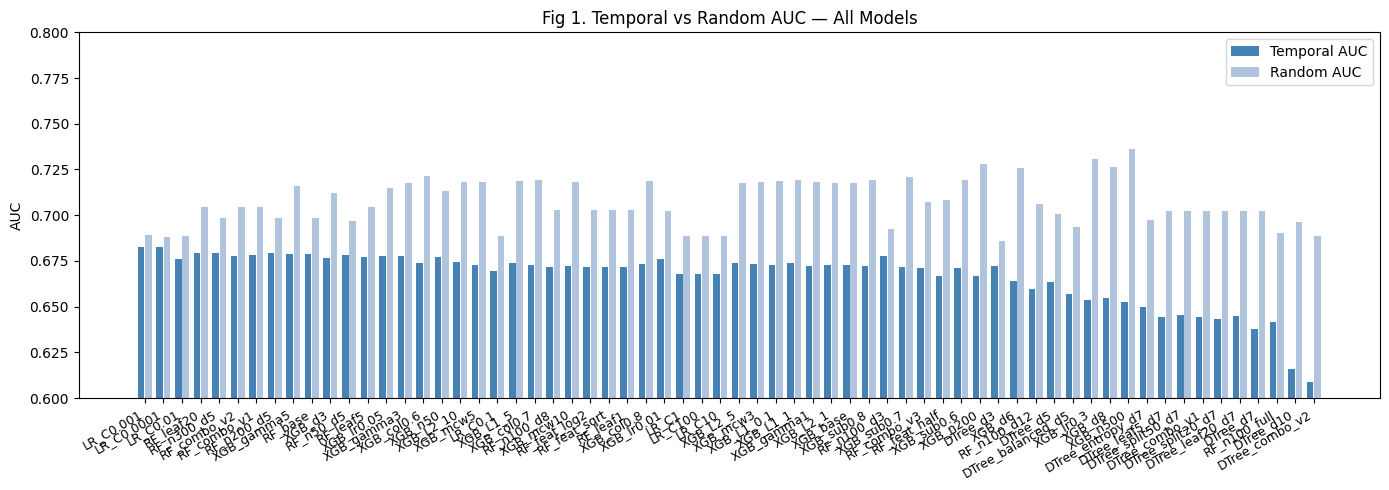

In [35]:
# ═══════════════════════════════════════════════════════════════════════
# Figure 1: Temporal AUC comparison (all model)
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 5))

model_names = df_results['Model'].tolist()
t_aucs = df_results['Temporal AUC'].tolist()
r_aucs = df_results['Random AUC'].tolist()

x = np.arange(len(model_names))
bars1 = ax.bar(x - 0.2, t_aucs, width=0.35, label='Temporal AUC', color='steelblue')
bars2 = ax.bar(x + 0.2, r_aucs, width=0.35, label='Random AUC',   color='lightsteelblue')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylim(0.60, 0.80)
ax.set_ylabel('AUC')
ax.set_title('Fig 1. Temporal vs Random AUC — All Models')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('/content/fig1_auc_comparison.png', dpi=150)
plt.show()

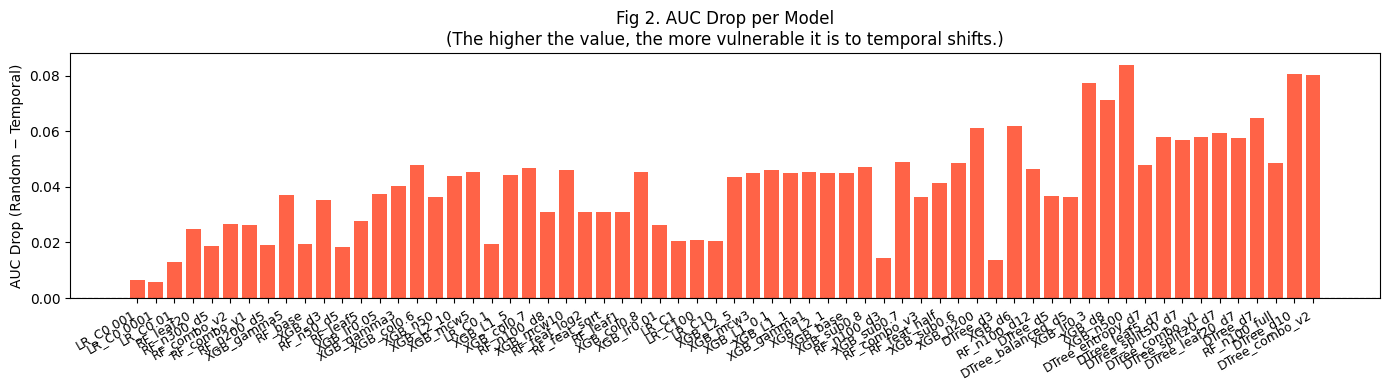

In [36]:
# ═══════════════════════════════════════════════════════════════════════
# Figure 2: AUC Drop (Temporal how much decrease)
# ═══════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(14, 4))

drops = df_results['AUC Drop'].tolist()
colors = ['tomato' if d > 0 else 'seagreen' for d in drops]

ax.bar(model_names, drops, color=colors)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(np.arange(len(model_names)))
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('AUC Drop (Random − Temporal)')
ax.set_title('Fig 2. AUC Drop per Model\n(The higher the value, the more vulnerable it is to temporal shifts.)')
plt.tight_layout()
plt.savefig('/content/fig2_auc_drop.png', dpi=150)
plt.show()

In [37]:
# Deprecated duplicate Figure 3 block removed.
# Use the current yearly-AUC Figure 3 cell below, which draws from `all_results` and `REPRESENTATIVE_MODELS`.


In [38]:
# Deprecated duplicate Figure 4 block removed.
# Use the current validation-ranking Figure 4 cell below, which saves `fig4_validation_auc.png`.


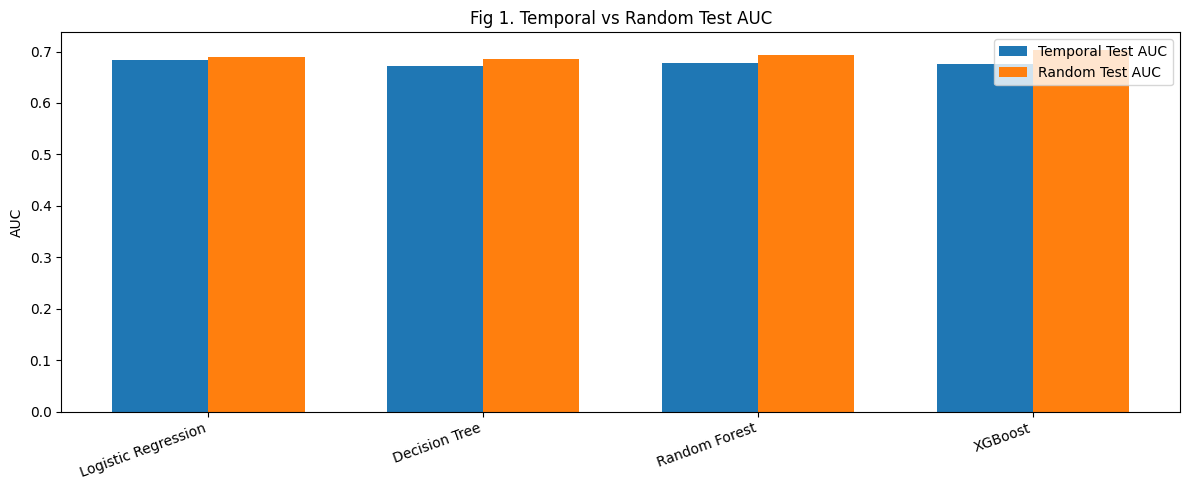

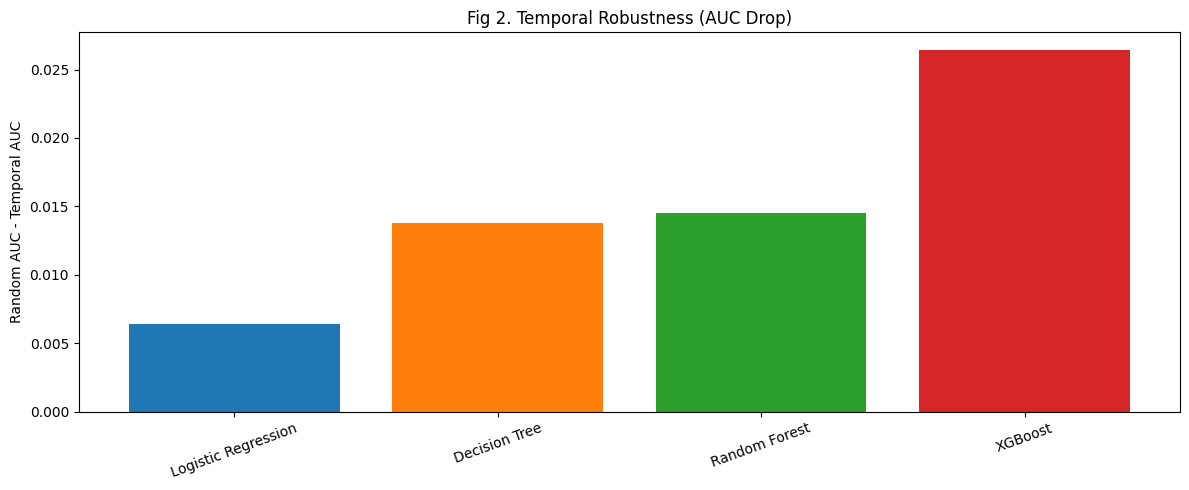

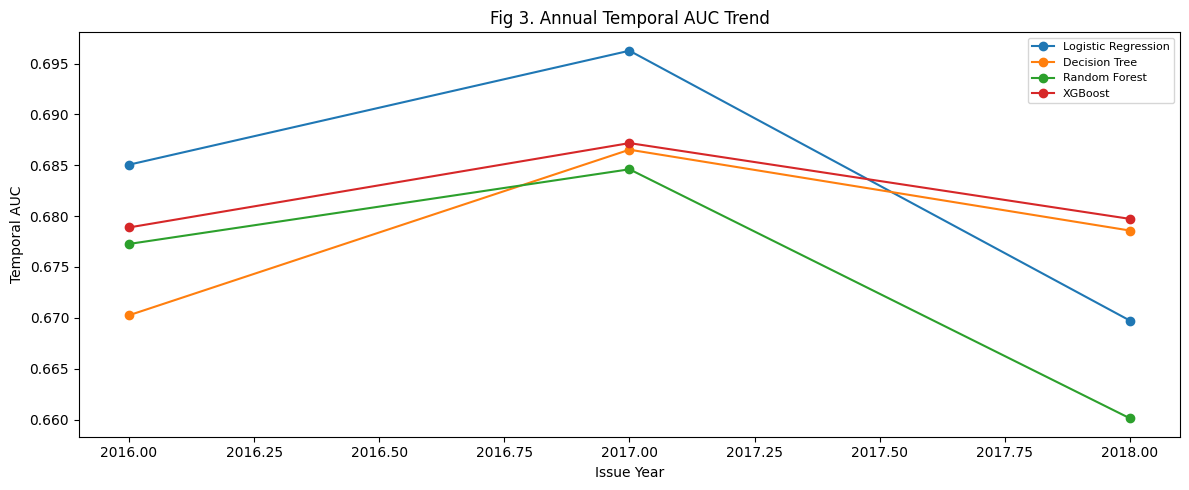

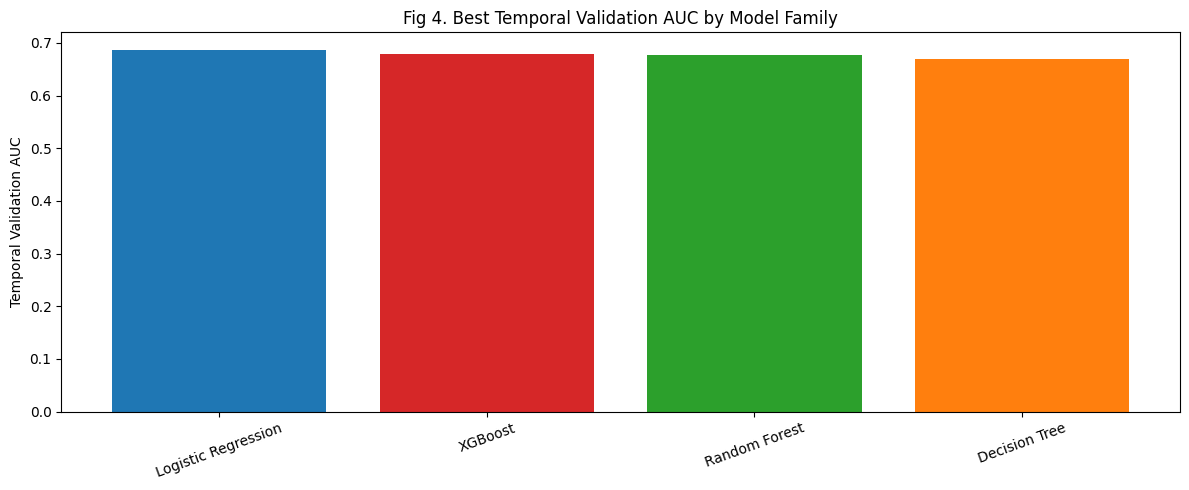

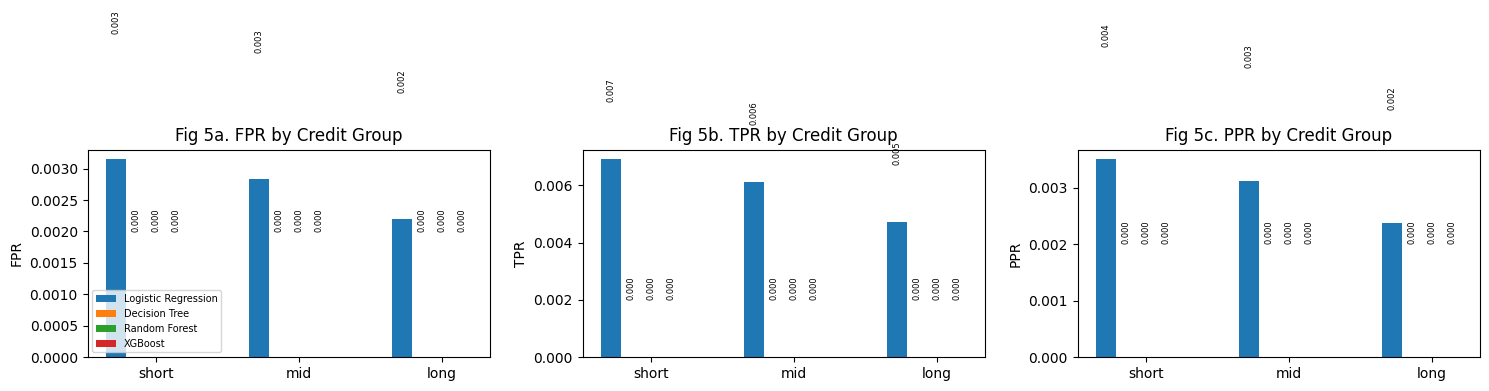

In [39]:
# ════════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

# Figure 1: Temporal vs random AUC for one representative per model family
family_order = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
family_display = {
    'Logistic Regression': 'Logistic Regression',
    'Decision Tree': 'Decision Tree',
    'Random Forest': 'Random Forest',
    'XGBoost': 'XGBoost',
}
family_colors = {
    'Logistic Regression': '#1f77b4',
    'Decision Tree': '#ff7f0e',
    'Random Forest': '#2ca02c',
    'XGBoost': '#d62728',
}

plot_df = df_representatives.copy()
plot_df['Family'] = plot_df['Model'].apply(infer_family)
plot_df['Family'] = pd.Categorical(plot_df['Family'], categories=family_order, ordered=True)
plot_df = plot_df.sort_values('Family').copy()
plot_df['Display'] = plot_df['Family'].map(family_display)

FAIR_MODELS_PLOT = plot_df['Model'].tolist()
FAIR_FAMILIES_PLOT = plot_df['Family'].astype(str).tolist()
FAIR_LABELS_PLOT = plot_df['Display'].tolist()
colors_fair = [family_colors.get(f, '#9467bd') for f in FAIR_FAMILIES_PLOT]

x = np.arange(len(plot_df))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, plot_df['Temporal AUC'], width=width, label='Temporal Test AUC', color='#1f77b4')
ax.bar(x + width/2, plot_df['Random AUC'], width=width, label='Random Test AUC', color='#ff7f0e')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Display'], rotation=20, ha='right')
ax.set_ylabel('AUC')
ax.set_title('Fig 1. Temporal vs Random Test AUC')
ax.legend()
plt.tight_layout()
plt.savefig('/content/fig1_auc_comparison.png', dpi=150)
plt.show()

# Figure 2: AUC drop for one representative per model family
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(plot_df['Display'], plot_df['AUC Drop'], color=[family_colors.get(f, '#2ca02c') for f in plot_df['Family'].astype(str)])
ax.set_ylabel('Random AUC - Temporal AUC')
ax.set_title('Fig 2. Temporal Robustness (AUC Drop)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('/content/fig2_auc_drop.png', dpi=150)
plt.show()

# Figure 3: Annual temporal AUC trend
fig, ax = plt.subplots(figsize=(12, 5))
for mname, family_label in zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT):
    year_map = all_results[mname]['yearly']
    years = sorted(year_map.keys())
    vals = [year_map[y] for y in years]
    ax.plot(years, vals, marker='o', label=family_label)
ax.set_xlabel('Issue Year')
ax.set_ylabel('Temporal AUC')
ax.set_title('Fig 3. Annual Temporal AUC Trend')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('/content/fig3_auc_over_time.png', dpi=150)
plt.show()

# Figure 4: Best validation AUC by model family
fig, ax = plt.subplots(figsize=(12, 5))
fig4_df = df_representatives.sort_values('Temporal Val AUC', ascending=False).copy()
fig4_df['Family'] = fig4_df['Model'].apply(infer_family)
fig4_df['Display'] = fig4_df['Family'].map(family_display)
ax.bar(fig4_df['Display'], fig4_df['Temporal Val AUC'], color=[family_colors.get(f, '#9467bd') for f in fig4_df['Family']])
ax.set_ylabel('Temporal Validation AUC')
ax.set_title('Fig 4. Best Temporal Validation AUC by Model Family')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('/content/fig4_validation_auc.png', dpi=150)
plt.show()

# Figure 5: Fairness by credit-history group at threshold 0.5
FAIR_MODELS_PLOT = REPRESENTATIVE_MODELS.copy()
family_map = dict(zip(representative_lookup['Model'], representative_lookup['Family']))
FAIR_LABELS_PLOT = [family_display.get(family_map.get(m, ''), m) for m in FAIR_MODELS_PLOT]
colors_fair = [family_colors.get(family_map.get(m, ''), '#9467bd') for m in FAIR_MODELS_PLOT]

credit_groups = ['short', 'mid', 'long']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['FPR', 'TPR', 'PPR']
for ax_i, metric in enumerate(metrics):
    x = np.arange(len(credit_groups))
    width = 0.14
    for j, (mname, family_label, col) in enumerate(zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT, colors_fair)):
        df_f = fairness_results.get(mname, {}).get('credit', pd.DataFrame(columns=['group'] + metrics))
        vals = df_f.set_index('group').reindex(credit_groups)[metric].fillna(0).tolist()
        offset = (j - len(FAIR_MODELS_PLOT) / 2) * width
        bars = axes[ax_i].bar(x + offset, vals, width=width, label=family_label, color=col)
        for bar, val in zip(bars, vals):
            axes[ax_i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                fontsize=6,
                rotation=90
            )
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(credit_groups)
    axes[ax_i].set_title(f'Fig 5{chr(97+ax_i)}. {metric} by Credit Group')
    axes[ax_i].set_ylabel(metric)
    if ax_i == 0:
        axes[ax_i].legend(fontsize=7)
plt.tight_layout()
plt.savefig('/content/fig5_fairness_credit.png', dpi=150)
plt.show()


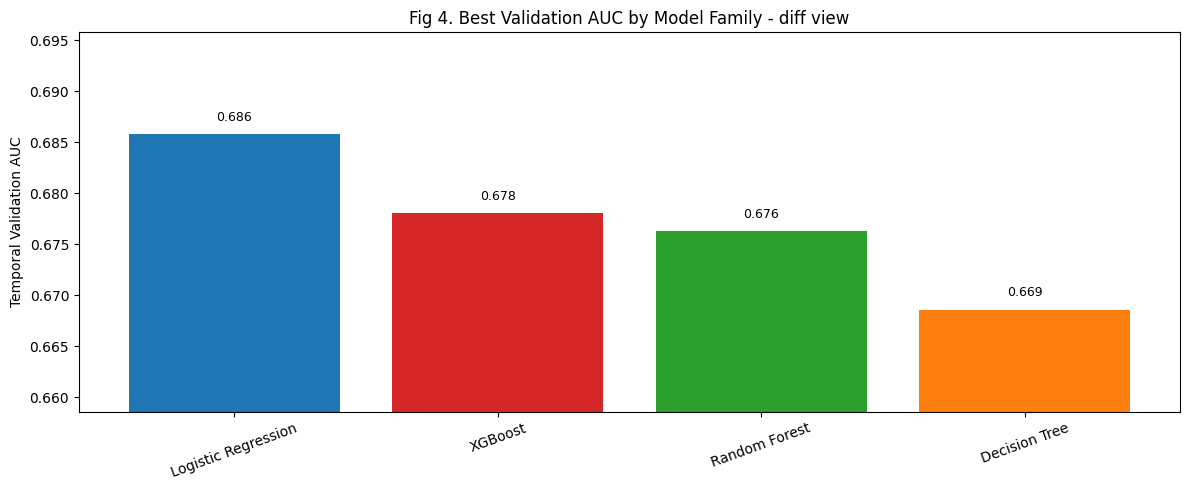

In [40]:
# Figure 4 alternate view: sorted high-to-low with a careful zoomed y-axis
fig4_alt_df = df_representatives.copy()
fig4_alt_df['Family'] = fig4_alt_df['Model'].apply(infer_family)
fig4_alt_df['Display'] = fig4_alt_df['Family'].map(family_display)
fig4_alt_df = fig4_alt_df.sort_values('Temporal Val AUC', ascending=False).copy()

ymin = max(0.0, fig4_alt_df['Temporal Val AUC'].min() - 0.01)
ymax = min(1.0, fig4_alt_df['Temporal Val AUC'].max() + 0.01)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(
    fig4_alt_df['Display'],
    fig4_alt_df['Temporal Val AUC'],
    color=[family_colors.get(f, '#9467bd') for f in fig4_alt_df['Family']]
)
ax.set_ylabel('Temporal Validation AUC')
ax.set_title('Fig 4. Best Validation AUC by Model Family - diff view')
ax.set_ylim(ymin, ymax)
ax.tick_params(axis='x', rotation=20)

for bar, val in zip(bars, fig4_alt_df['Temporal Val AUC']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


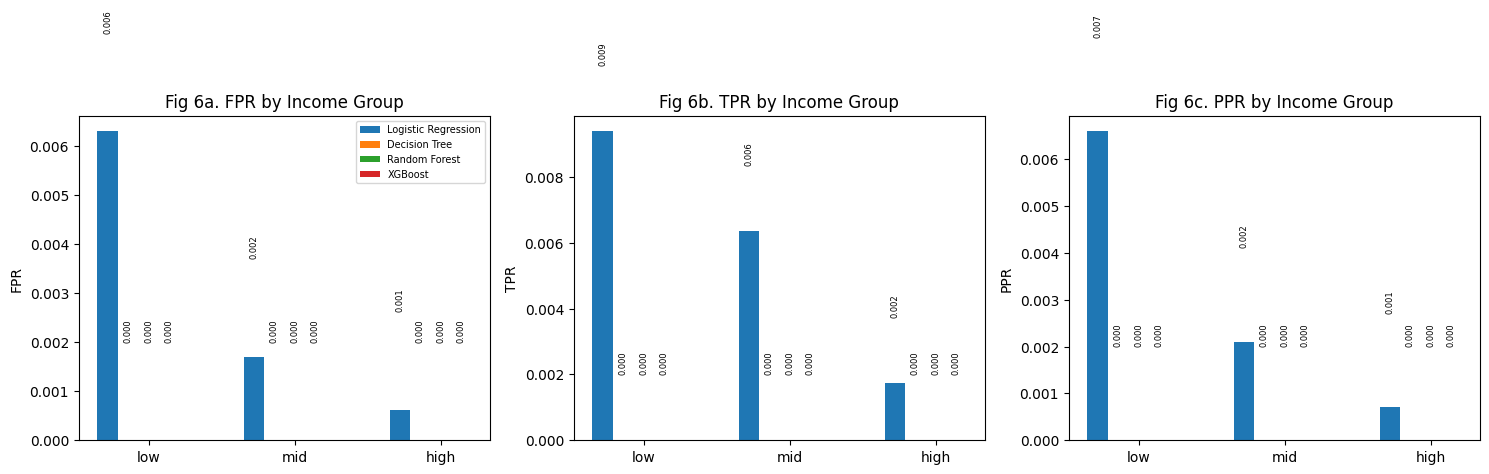

In [41]:
# Figure 6: Fairness by income group at threshold 0.5
FAIR_MODELS_PLOT = REPRESENTATIVE_MODELS.copy()
family_map = dict(zip(representative_lookup['Model'], representative_lookup['Family']))
FAIR_LABELS_PLOT = [family_display.get(family_map.get(m, ''), m) for m in FAIR_MODELS_PLOT]
colors_fair = [family_colors.get(family_map.get(m, ''), '#9467bd') for m in FAIR_MODELS_PLOT]

income_groups = ['low', 'mid', 'high']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax_i, metric in enumerate(metrics):
    x = np.arange(len(income_groups))
    width = 0.14
    for j, (mname, family_label, col) in enumerate(zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT, colors_fair)):
        df_f = fairness_results.get(mname, {}).get('income', pd.DataFrame(columns=['group'] + metrics))
        vals = df_f.set_index('group').reindex(income_groups)[metric].fillna(0).tolist()
        offset = (j - len(FAIR_MODELS_PLOT) / 2) * width
        bars = axes[ax_i].bar(x + offset, vals, width=width, label=family_label, color=col)
        for bar, val in zip(bars, vals):
            axes[ax_i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{val:.3f}',
                ha='center',
                va='bottom',
                fontsize=6,
                rotation=90
            )
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(income_groups)
    axes[ax_i].set_title(f'Fig 6{chr(97+ax_i)}. {metric} by Income Group')
    axes[ax_i].set_ylabel(metric)
    if ax_i == 0:
        axes[ax_i].legend(fontsize=7)
plt.tight_layout()
plt.savefig('/content/fig6_fairness_income.png', dpi=150)
plt.show()


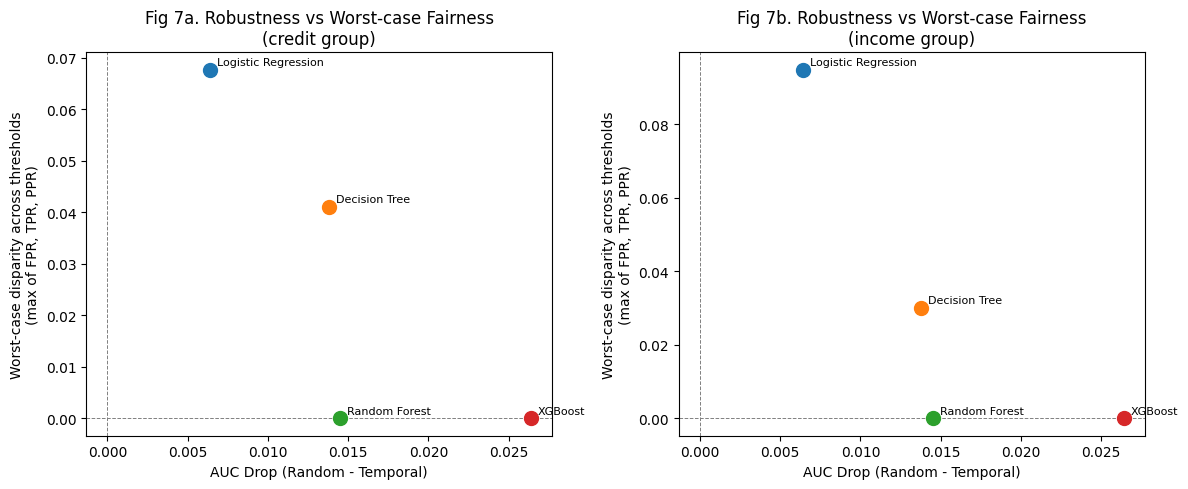

In [42]:
# Figure 7: Robustness vs worst-case fairness disparity
FAIR_MODELS_PLOT = REPRESENTATIVE_MODELS.copy()
family_map = dict(zip(representative_lookup['Model'], representative_lookup['Family']))
FAIR_LABELS_PLOT = [family_display.get(family_map.get(m, ''), m) for m in FAIR_MODELS_PLOT]
colors_fair = [family_colors.get(family_map.get(m, ''), '#9467bd') for m in FAIR_MODELS_PLOT]

tradeoff_df = df_fairness_summary[df_fairness_summary['Model'].isin(FAIR_MODELS_PLOT)].copy()
tradeoff_df['Worst Credit Overall_disp'] = tradeoff_df[['Worst Credit FPR_disp', 'Worst Credit TPR_disp', 'Worst Credit PPR_disp']].max(axis=1)
tradeoff_df['Worst Income Overall_disp'] = tradeoff_df[['Worst Income FPR_disp', 'Worst Income TPR_disp', 'Worst Income PPR_disp']].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax_i, (y_col, title_suffix) in enumerate([
    ('Worst Credit Overall_disp', 'credit group'),
    ('Worst Income Overall_disp', 'income group'),
]):
    for mname, family_label, col in zip(FAIR_MODELS_PLOT, FAIR_LABELS_PLOT, colors_fair):
        row = tradeoff_df[tradeoff_df['Model'] == mname].iloc[0]
        x_val = row['AUC Drop']
        y_val = row[y_col]
        axes[ax_i].scatter(x_val, y_val, color=col, s=100, label=family_label, zorder=3)
        axes[ax_i].annotate(family_label, (x_val, y_val), textcoords='offset points', xytext=(5, 3), fontsize=8)
    axes[ax_i].set_xlabel('AUC Drop (Random - Temporal)')
    axes[ax_i].set_ylabel('Worst-case disparity across thresholds\n(max of FPR, TPR, PPR)')
    axes[ax_i].set_title(f'Fig 7{chr(97+ax_i)}. Robustness vs Worst-case Fairness\n({title_suffix})')
    axes[ax_i].axhline(0, color='gray', linestyle='--', linewidth=0.7)
    axes[ax_i].axvline(0, color='gray', linestyle='--', linewidth=0.7)
plt.tight_layout()
plt.savefig('/content/fig7_tradeoff.png', dpi=150)
plt.show()


## 8. Output Final Summary Table (For Presentation)

In [43]:
# Representative summary table aligned with the current pipeline
df_summary = df_ranked[df_ranked['Model'].isin(REPRESENTATIVE_MODELS)].copy()
df_summary['Model'] = pd.Categorical(df_summary['Model'], categories=REPRESENTATIVE_MODELS, ordered=True)
df_summary = df_summary.sort_values('Model')
print('=== Summary Table (Representative Models) ===')
print(df_summary.to_string(index=False))

df_summary.to_csv('/content/prefinal_summary.csv', index=False)
df_results.to_csv('/content/prefinal_full_results.csv', index=False)
print('\nCSV saved: prefinal_summary.csv, prefinal_full_results.csv')

=== Summary Table (Representative Models) ===
     Model  Temporal Val AUC  Temporal AUC  Accuracy  AUC Drop  Worst Credit FPR_disp  Worst Income FPR_disp  Worst Credit TPR_disp  Worst Income TPR_disp  Worst Credit PPR_disp  Worst Income PPR_disp  _fair_norm  composite_score
 LR_C0.001            0.6858        0.6827    0.9138    0.0064                 0.0426                 0.0904                 0.0677                 0.0948                 0.0479                 0.0943    0.380944         0.155682
  DTree_d3            0.6686        0.6723    0.9158    0.0138                 0.0238                 0.0141                 0.0411                 0.0301                 0.0280                 0.0150    0.163068         0.139934
RF_n100_d3            0.6763        0.6778    0.9158    0.0145                 0.0000                 0.0000                 0.0000                 0.0000                 0.0000                 0.0000    0.000000         0.060449
XGB_lr0.01            0.6781      

## 9. Save Files (Google Drive)
Save Resulting PNG + CSV to Drive

In [44]:
import shutil, os

SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/CSCI567'
os.makedirs(SAVE_DIR, exist_ok=True)

files_to_save = [
    '/content/fig1_auc_comparison.png',
    '/content/fig2_auc_drop.png',
    '/content/fig3_auc_over_time.png',
    '/content/fig4_validation_auc.png',
    '/content/fig5_fairness_credit.png',
    '/content/fig6_fairness_income.png',
    '/content/fig7_tradeoff.png',
    '/content/prefinal_summary.csv',
    '/content/prefinal_full_results.csv',
]

for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, SAVE_DIR)
        print(f'Saved: {os.path.basename(f)}')
    else:
        print(f'NOT FOUND: {f}')

Saved: fig1_auc_comparison.png
Saved: fig2_auc_drop.png
Saved: fig3_auc_over_time.png
Saved: fig4_validation_auc.png
Saved: fig5_fairness_credit.png
Saved: fig6_fairness_income.png
Saved: fig7_tradeoff.png
Saved: prefinal_summary.csv
Saved: prefinal_full_results.csv
